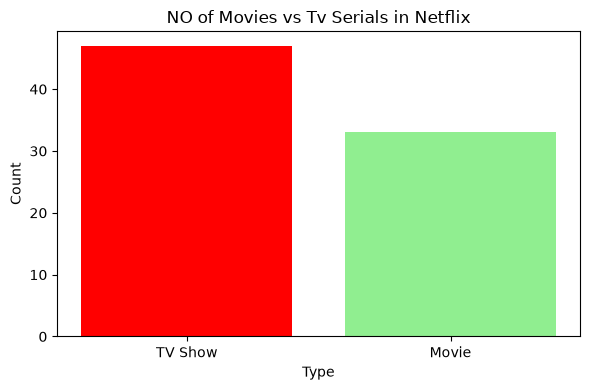

In [ ]:
#step 1 import the libraries 
import pandas as pd
import matplotlib.pyplot as plt

 
df=pd.read_csv("netflix_realistic_80.csv")


# clean the data using pandas
df=df.dropna(subset=['type','title','duration','listed_in','description'])



#1st task started :i show bar chart showing user who watch movies and serials
type_count = df['type'].value_counts()# it count the values from types like movies=30, serials =40
plt.figure(figsize=(6,4))
plt.bar(
    type_count.index,type_count.values,color=["Red","lightgreen"]

)
plt.title(" NO of Movies vs Tv Serials in Netflix ")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("NO of Movies vs Tv Serials in Netflix.png")
plt.show()


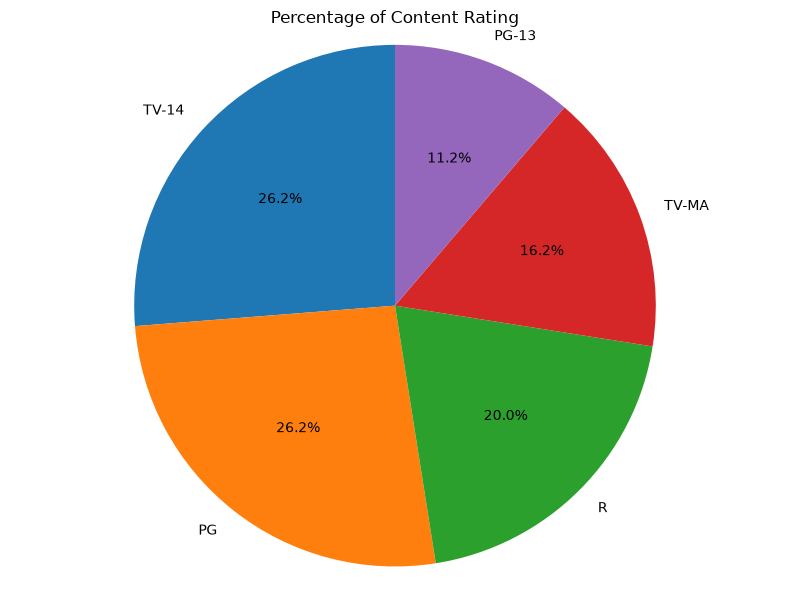

In [2]:
#Rating count

rating_count = df['rating'].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    rating_count,
    labels=rating_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage of Content Rating")
plt.axis('equal')

plt.tight_layout()
plt.savefig("Percentage_of_Content_Rating.png")


movie_df=df[df['type']=="Movie"].copy()
movie_df["duration_int"]=movie_df['duration'].str.replace('min','').astype(int)
plt.show()

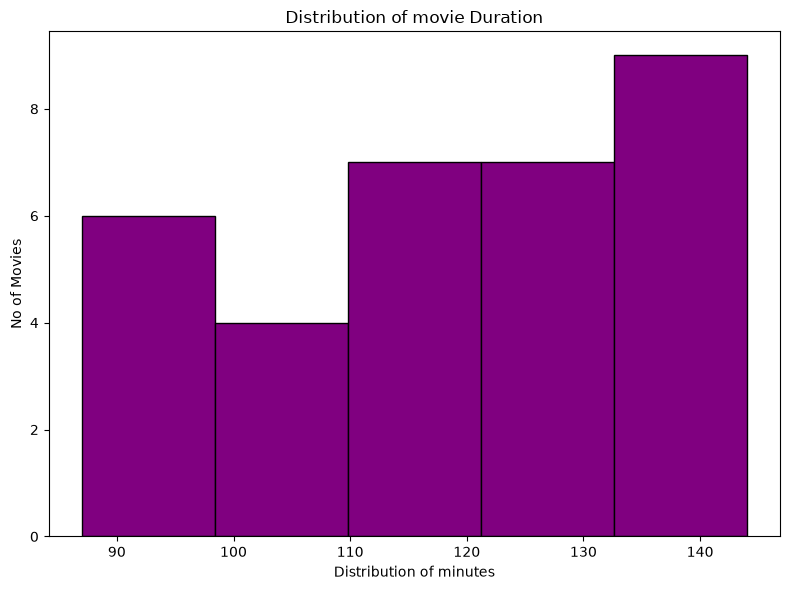

In [3]:

#Histogram
plt.figure(figsize=(8,6))
plt.hist(movie_df["duration_int"],bins=5,color ="purple",edgecolor="black")
plt.xlabel("Distribution of minutes")
plt.ylabel("No of Movies")
plt.title("Distribution of movie Duration")
plt.tight_layout()
plt.savefig(" Movie duration Histogram.png")
plt.show()
# movie_df=df[df['type']=="movie"].copy()
# movie_df['duration_int']=movie_df['duration'].str.replace('min','').astype(int)[]


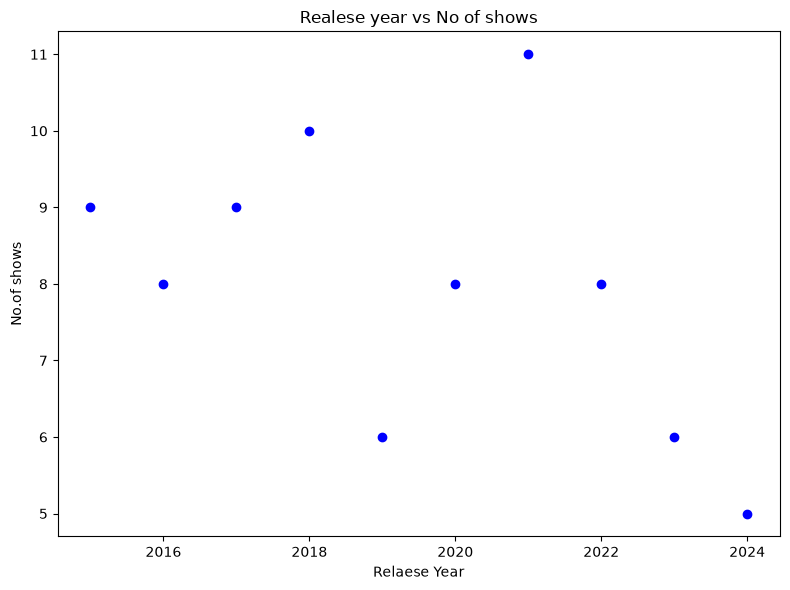

In [4]:

#Scatterplot
release_count=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,6))

plt.scatter(release_count.index,release_count.values,marker='o',color="Blue")
plt.title("Realese year vs No of shows")
plt.xlabel("Relaese Year")
plt.ylabel("No.of shows")
plt.tight_layout()
plt.savefig("Release year_scatterplt.png")
plt.show()


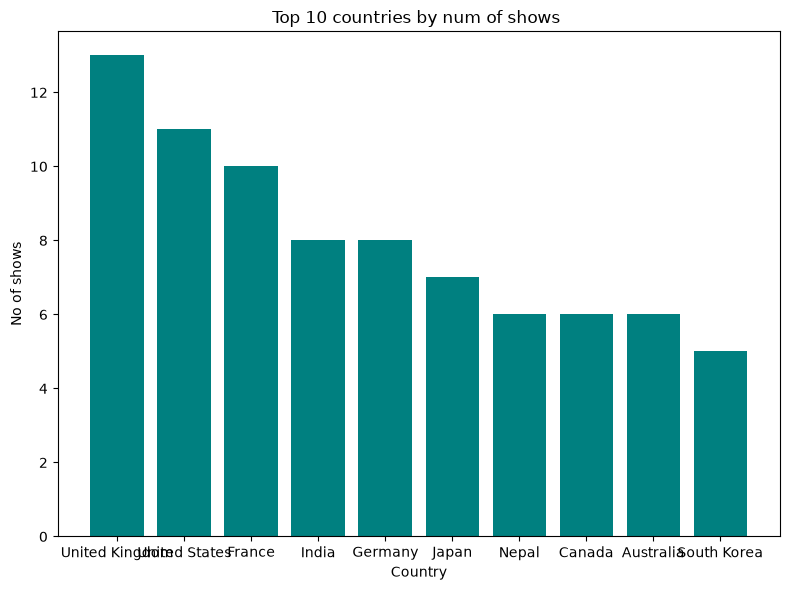

In [5]:
#Bar chart to show top countires to watch 
country_Count=df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.bar(country_Count.index,country_Count.values,color="teal")
plt.title("Top 10 countries by num of shows ")
plt.xlabel("Country")
plt.ylabel("No of shows")
plt.tight_layout()
plt.savefig("Top 10 countries.png")
plt.show()

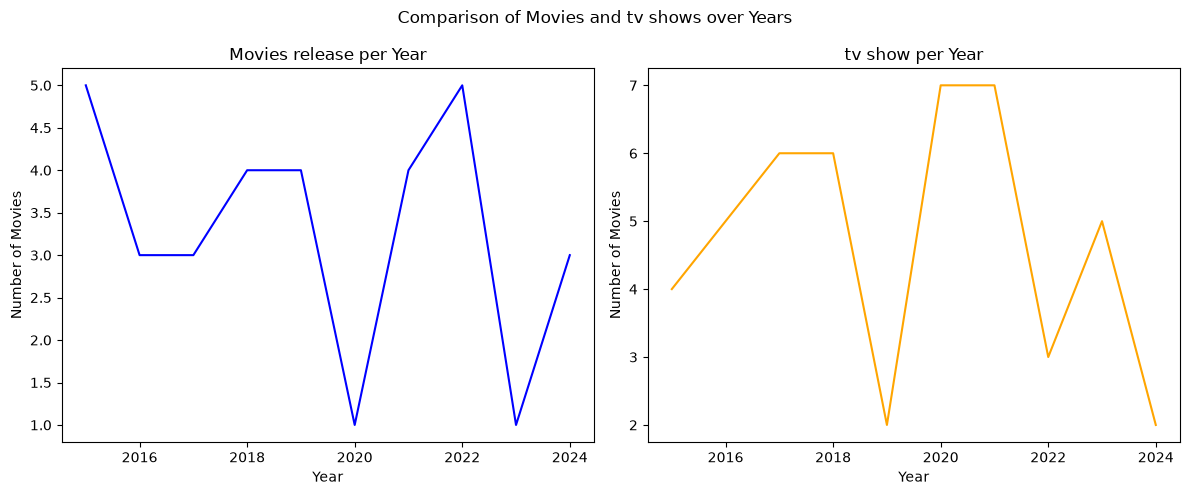

In [6]:

#subplot

content_by_year=df.groupby(['release_year','type']).size().unstack().fillna(0)
fig,ax=plt.subplots(1,2,figsize=(12,5))#professional way

#first plot: movies show
ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title("Movies release per Year")
ax[0].set_xlabel('Year')
ax[0].set_ylabel("Number of Movies")

#second plot:tv show

ax[1].plot(content_by_year.index,content_by_year['TV Show'],color='orange')
ax[1].set_title("tv show per Year")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Number of Movies")

fig.suptitle("Comparison of Movies and tv shows over Years")
plt.tight_layout()
plt.savefig("movies and tv shows comparision.png")
plt.show()